Lasso Regression is a linear regression technique that uses L1 regularization to penalize the absolute values of coefficients. It not only reduces overfitting but can also perform feature selection by shrinking some coefficients exactly to zero, effectively removing less important features from the model."


1. Cost Formula

Lasso regression adds an L1 penalty to the usual linear regression loss:

Cost (Loss):-
  Cost (Loss)=i=1∑n (yi −y^ i )2+λj=1∑p ∣βj ∣

  where
  yi = actual target
  y^ i = predicted target
  λ = regularization parameter controlling shrinkage
λ increases, more coefficients are driven exactly to 0, performing feature selection.

2. When to Use Lasso

    High-dimensional data where many features might be irrelevant

    You want feature selection automatically

    Reduce overfitting when features are correlated but you want a sparse model

    Preferable when you suspect only a few features are actually important

3. How It Works

    Start with a normal linear regression model.

    Add the L1 penalty term to the cost function.

    Use optimization (like coordinate descent) to find coefficients that minimize the penalized loss.

    Coefficients of less important features shrink to exactly zero, keeping only key features.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

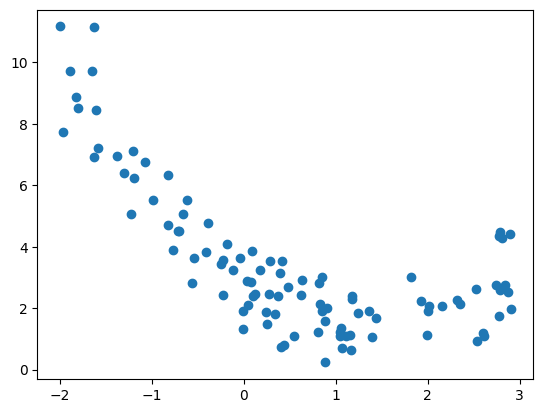

In [3]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

### Apply lasso

/opt/homebrew/lib/python3.11/site-packages/sklearn/base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.943e+01, tolerance: 5.793e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


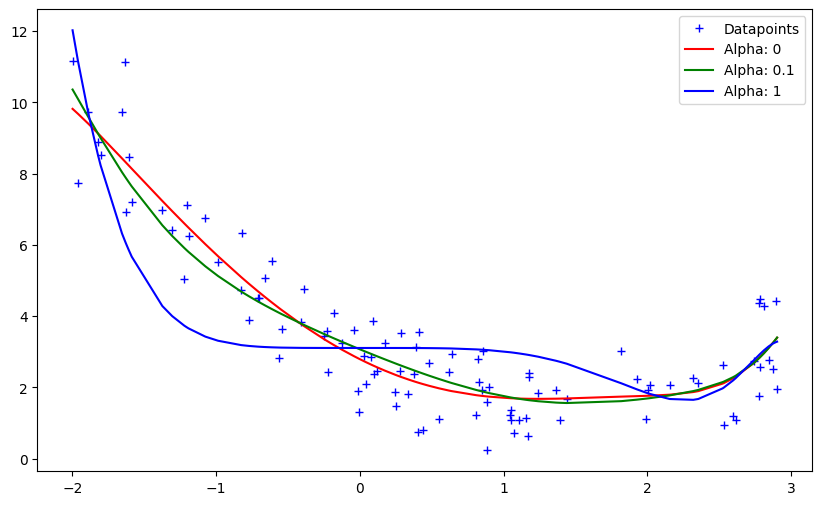

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

def get_preds_lasso(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('lasso', Lasso(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 0.1, 1]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_lasso(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()